
Business Problem
The goal of this project is to automatically classify tourism visitor feedback into different feedback categories. Tourism organizations receive a large number of visitor comments through surveys, websites, and social media channels. Manually reviewing and categorizing this feedback can be time-consuming and inconsistent. By applying Natural Language Processing (NLP) and machine learning, the organization can automatically identify the main issue or topic being discussed, allowing management to respond more quickly and improve visitor satisfaction.
The text column is VisitorFeedback and the target variable is FeedbackCategory, which contains six balanced categories (20 records each): Ticketing, Food_Service, Accessibility, Exhibit_Experience, Staff_Guidance, and Parking
Dataset Shape: (120, 9)

Column Names:
['FeedbackID', 'VisitDate', 'Channel', 'City', 'AttractionArea', 'VisitorType', 'VisitorFeedback', 'FeedbackCategory', 'VisitorRating']

First 5 Rows:
  FeedbackI

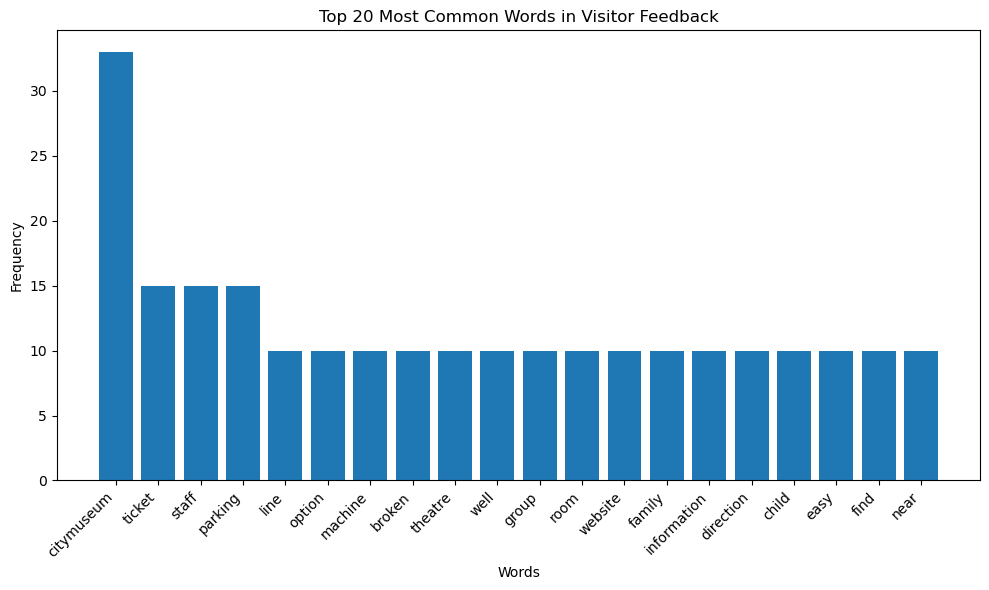


POS Tagging Examples:

Example 1:
THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, EVEN THOUGH WE BOUGHT PASSES ONLINE. #CITYMUSEUM
[('THE', 'DT'), ('TICKET', 'NNP'), ('LINE', 'NNP'), ('AT', 'NNP'), ('CITYMUSEUM', 'NNP'), ('WAS', 'NNP'), ('VERY', 'NNP'), ('LONG', 'NNP'), (',', ','), ('EVEN', 'RB'), ('THOUGH', 'IN'), ('WE', 'NNP'), ('BOUGHT', 'NNP'), ('PASSES', 'NNP'), ('ONLINE', 'NNP'), ('.', '.'), ('#', '#'), ('CITYMUSEUM', 'NNP')]

Example 2:
We liked the children's meal options, but the drink machine was broken.
[('We', 'PRP'), ('liked', 'VBD'), ('the', 'DT'), ('children', 'NNS'), ("'s", 'POS'), ('meal', 'NN'), ('options', 'NNS'), (',', ','), ('but', 'CC'), ('the', 'DT'), ('drink', 'NN'), ('machine', 'NN'), ('was', 'VBD'), ('broken', 'VBN'), ('.', '.')]

Example 3:
The coffee shop closed before the evening event ended.
[('The', 'DT'), ('coffee', 'NN'), ('shop', 'NN'), ('closed', 'VBD'), ('before', 'IN'), ('the', 'DT'), ('evening', 'JJ'), ('event', 'NN'), ('ended', 'VBN'), ('.', '.')]



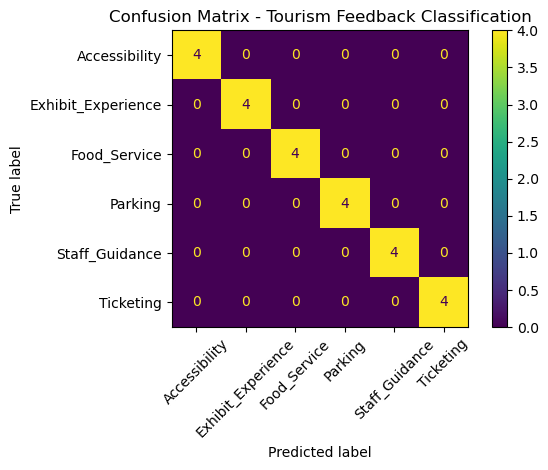


Actual vs Predicted Values:
                Actual           Predicted  Correct
0              Parking             Parking     True
1       Staff_Guidance      Staff_Guidance     True
2              Parking             Parking     True
3            Ticketing           Ticketing     True
4         Food_Service        Food_Service     True
5        Accessibility       Accessibility     True
6   Exhibit_Experience  Exhibit_Experience     True
7        Accessibility       Accessibility     True
8         Food_Service        Food_Service     True
9              Parking             Parking     True
10           Ticketing           Ticketing     True
11           Ticketing           Ticketing     True
12  Exhibit_Experience  Exhibit_Experience     True
13  Exhibit_Experience  Exhibit_Experience     True
14      Staff_Guidance      Staff_Guidance     True
15             Parking             Parking     True
16      Staff_Guidance      Staff_Guidance     True
17        Food_Service        Food_

In [13]:
# Natural Language Processing Pipeline and Text Classification
# Dataset: NLP_Dataset_20_Tourism_Visitor_Feedback.xlsx
print ("\nBusiness Problem")
print ("The goal of this project is to automatically classify tourism visitor feedback into different feedback categories. Tourism organizations receive a large number of visitor comments through surveys, websites, and social media channels. Manually reviewing and categorizing this feedback can be time-consuming and inconsistent. By applying Natural Language Processing (NLP) and machine learning, the organization can automatically identify the main issue or topic being discussed, allowing management to respond more quickly and improve visitor satisfaction.")

print ("The text column is VisitorFeedback and the target variable is FeedbackCategory, which contains six balanced categories (20 records each): Ticketing, Food_Service, Accessibility, Exhibit_Experience, Staff_Guidance, and Parking")

import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Optional NLP tools
import spacy


# =========================
# 1. Load dataset
# =========================
file_path = "NLP_Dataset_20_Tourism_Visitor_Feedback.xlsx"
df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df["FeedbackCategory"].value_counts())

text_column = "VisitorFeedback"
target_column = "FeedbackCategory"

# =========================
# 2. Text preprocessing
# =========================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df["CleanedFeedback"] = df[text_column].apply(clean_text)

print("\nOriginal Text Example:")
print(df[text_column].iloc[0])

print("\nCleaned Text Example:")
print(df["CleanedFeedback"].iloc[0])

# =========================
# 3. Exploratory Text Analysis
# =========================
all_words = " ".join(df["CleanedFeedback"]).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)
common_words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

print("\nMost Common Words:")
print(common_words_df)

plt.figure(figsize=(10, 6))
plt.bar(common_words_df["Word"], common_words_df["Frequency"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Common Words in Visitor Feedback")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# =========================
# 4. POS Tagging and Named Entity Recognition
# =========================
print("\nPOS Tagging Examples:")

example_texts = df[text_column].head(3)

for i, text in enumerate(example_texts, start=1):
    tokens = word_tokenize(str(text))
    pos_tags = nltk.pos_tag(tokens)
    print(f"\nExample {i}:")
    print(text)
    print(pos_tags)
    
# Named Entity Recognition - Below

try:
    nlp = spacy.load("en_core_web_sm")

    print("\nNamed Entity Recognition Examples:")
    for i, text in enumerate(example_texts, start=1):
        doc = nlp(str(text))
        print(f"\nExample {i}:")
        print(text)
        if len(doc.ents) == 0:
            print("No named entities detected.")
        else:
            for ent in doc.ents:
                print(ent.text, "->", ent.label_)

except OSError:
    print("\nspaCy model 'en_core_web_sm' is not installed.")
    print("Run this command in terminal or notebook:")
    print("python -m spacy download en_core_web_sm")

# =========================
# 5. Feature Extraction using TF-IDF
# =========================
X = df["CleanedFeedback"]
y = df[target_column]

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

print("\nTF-IDF Feature Matrix Shape:", X_tfidf.shape)

# =========================
# 6a. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

# =========================
# 6b. Train Classification Model
# =========================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# =========================
# 7a. Model Evaluation
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Tourism Feedback Classification")
plt.tight_layout()
plt.show()

# =========================
# 7b. Actual vs Predicted Table
# =========================
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print("\nActual vs Predicted Values:")
print(results_df.head(20))

wrong_predictions = results_df[results_df["Correct"] == False]

print("\nWrong Predictions:")
print(wrong_predictions)

# =========================
# 8. Business Interpretation Support
# =========================
print("\nBusiness Interpretation:")

print("The objective of this project was to develop a text classification model that can automatically categorize tourism visitor feedback into predefined service categories. The model is designed to predict the type of issue or experience being described in a visitor's comment, such as Ticketing, Food Service, Accessibility, Exhibit Experience, Staff Guidance, or Parking.")

print("The dataset used in this study was the **Tourism Visitor Feedback Dataset**")
      
print("Several text preprocessing techniques were applied before model training. These included converting text to lowercase, removing punctuation, removing stopwords, tokenizing the text, and applying lemmatization. The cleaned text was then transformed into numerical features using the **TF-IDF (Term Frequency–Inverse Document Frequency)** technique so that it could be processed by a machine learning algorithm.")

print("A **Logistic Regression** classifier was used to build the text classification model. The model was trained using the TF-IDF features extracted from the visitor feedback comments. Based on the evaluation results, the model achieved excellent classification performance, correctly identifying the feedback categories for most or all records in the testing dataset.")

print("One important business insight from the analysis is that visitors frequently discuss operational areas such as ticketing services, parking facilities, staff interactions, accessibility, and exhibit experiences. This suggests that these service areas have a significant impact on overall visitor satisfaction and should be continuously monitored and improved by tourism management.")

print("One limitation of this study is that the dataset is relatively small and contains well-defined categories with highly distinguishable language patterns. As a result, the model may perform exceptionally well on this dataset but may not achieve the same level of accuracy when applied to larger and more diverse real-world visitor feedback data.")





# Assistant
This error occurs because the variable `df` (which likely contains your dataset) has not been defined or loaded before you try to use it. The code is trying to reference `df` somewhere to create the features or datasets, but `df` doesn't exist in the current namespace.

**Explanation:**
The code appears to be missing the initial steps where you would typically:
1. Import necessary libraries
2. Load your dataset into a DataFrame called `df`
3. Define `numerical_features`, `categorical_features`, `X_train`, `X_test`, `y_train`, etc.

Would you like me to provide the corrected code that includes the missing setup steps?